# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan

- Nama: Arisyi Said Tanjung
- Email: arisyisaid14@gmail.com
- Id Dicoding:arisyisaid

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, roc_curve, auc
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

In [2]:
#set styles
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

### Menyiapkan data yang akan digunakan

In [3]:
df = pd.read_csv("/content/data.csv", sep=";")
print('data.csv shape: ', df.shape)

df.head()

data.csv shape:  (4424, 37)


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [5]:
df.describe()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [6]:
df.isnull().sum()

,0
Marital_status,0
Application_mode,0
Application_order,0
Course,0
Daytime_evening_attendance,0
Previous_qualification,0
Previous_qualification_grade,0
Nacionality,0
Mothers_qualification,0
Fathers_qualification,0


In [7]:
print(df['Status'].value_counts())

Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


## Data Preparation / Preprocessing

In [8]:
#Encode Target
le = LabelEncoder()
df['Status_encoded'] = le.fit_transform(df['Status'])
print("Encode Mapping:" , dict(zip(le.classes_, le.transform(le.classes_))))

Encode Mapping: {'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}


In [9]:
## Add Feature Engineering, because using default feature keep the data in 75% Accuracy
# 1st semester approval rate
df['approval_rate_1st'] = df['Curricular_units_1st_sem_approved'] / (df['Curricular_units_1st_sem_enrolled'] + 1e-6)
# 2nd semester approval rate
df['approval_rate_2nd'] = df['Curricular_units_2nd_sem_approved'] / (df['Curricular_units_2nd_sem_enrolled'] + 1e-6)
# Average grade across both semesters
df['grade_avg'] = (df['Curricular_units_1st_sem_grade'] + df['Curricular_units_2nd_sem_grade']) / 2
# Failure rates
df['failure_rate_1st'] = (df['Curricular_units_1st_sem_enrolled'] - df['Curricular_units_1st_sem_approved']) / (df['Curricular_units_1st_sem_enrolled'] + 1e-6)
df['failure_rate_2nd'] = (df['Curricular_units_2nd_sem_enrolled'] - df['Curricular_units_2nd_sem_approved']) / (df['Curricular_units_2nd_sem_enrolled'] + 1e-6)

# Drop the original columns that are now represented by rates to reduce multicollinearity
cols_to_drop = ['Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_approved',
                'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_approved',
                'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_grade']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')
print("Dropped original raw columns to avoid redundancy. New features added.")

Dropped original raw columns to avoid redundancy. New features added.


In [10]:
#separate features and target

X = df.drop(['Status', 'Status_encoded'], axis=1)
y = df['Status_encoded']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")


Features shape: (4424, 35)
Target shape: (4424,)


In [11]:
#handle missing Value (?)
num_cols = X.select_dtypes(include=[np.number]).columns
imputer = SimpleImputer(strategy='median')
X[num_cols] = imputer.fit_transform(X[num_cols])
print(f"Missing values after imputation: {X.isnull().sum().sum()}")


Missing values after imputation: 0


In [12]:
#check data type
print("\nFeature data types after cleaning:")
print(X.dtypes.value_counts())


Feature data types after cleaning:
float64    35
Name: count, dtype: int64


In [13]:
#Split data training and test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train class distribution:\n{pd.Series(y_train).value_counts(normalize=True)}")


Train shape: (3539, 35), Test shape: (885, 35)
Train class distribution:
Status_encoded
2    0.499294
0    0.321277
1    0.179429
Name: proportion, dtype: float64


### Exploratory Corelation

In [14]:
#Feature grouping
demographic = ['Marital_status', 'Gender', 'Age_at_enrollment', 'Nacionality',
               'Mothers_qualification', 'Fathers_qualification', 'Mothers_occupation',
               'Fathers_occupation', 'Displaced', 'Educational_special_needs']

academic = ['Previous_qualification', 'Previous_qualification_grade', 'Admission_grade',
            'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_without_evaluations',
            'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_credited',
            'Curricular_units_2nd_sem_without_evaluations',
            'approval_rate_1st', 'approval_rate_2nd', 'grade_avg', 'failure_rate_1st', 'failure_rate_2nd']

social_economic = ['Application_mode', 'Application_order', 'Course', 'Daytime_evening_attendance',
                   'Tuition_fees_up_to_date', 'Scholarship_holder', 'Debtor',
                   'Unemployment_rate', 'Inflation_rate', 'GDP']

all_cols = demographic + academic + social_economic
existing_cols = [c for c in all_cols if c in X_train.columns]
missing = [c for c in all_cols if c not in X_train.columns]
if missing:
    print(f"Warning: These columns are missing: {missing}")

In [15]:
#Correlations with target (absolute)
correlations = X_test[existing_cols].corrwith(y_test).abs().sort_values(ascending=False)
print("\nTop 15 correlated features (absolute):")
print(correlations.head(15))


Top 15 correlated features (absolute):
failure_rate_2nd                                0.706321
approval_rate_2nd                               0.702466
failure_rate_1st                                0.652104
approval_rate_1st                               0.641578
grade_avg                                       0.551318
Tuition_fees_up_to_date                         0.404496
Scholarship_holder                              0.314907
Gender                                          0.237171
Age_at_enrollment                               0.235585
Debtor                                          0.202668
Application_mode                                0.163398
Curricular_units_2nd_sem_without_evaluations    0.125624
Curricular_units_2nd_sem_credited               0.119752
Admission_grade                                 0.116590
Curricular_units_2nd_sem_evaluations            0.108317
dtype: float64


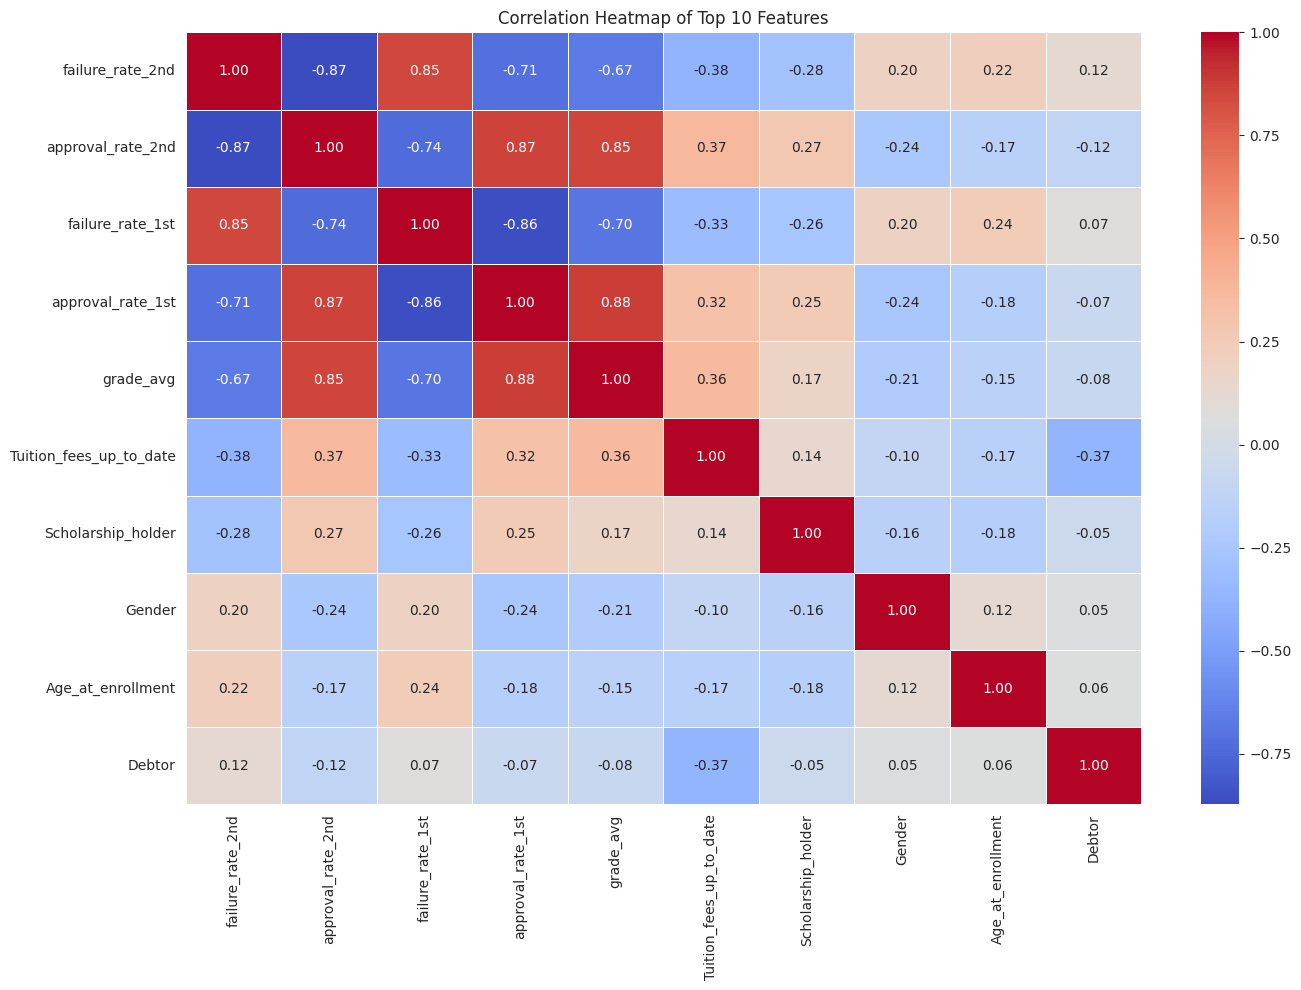

In [16]:
#Heatmap of top 10 features
plt.figure(figsize=(14, 10))
top10 = correlations.head(10).index
sns.heatmap(X_test[top10].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Top 10 Features')
plt.tight_layout()
plt.show()

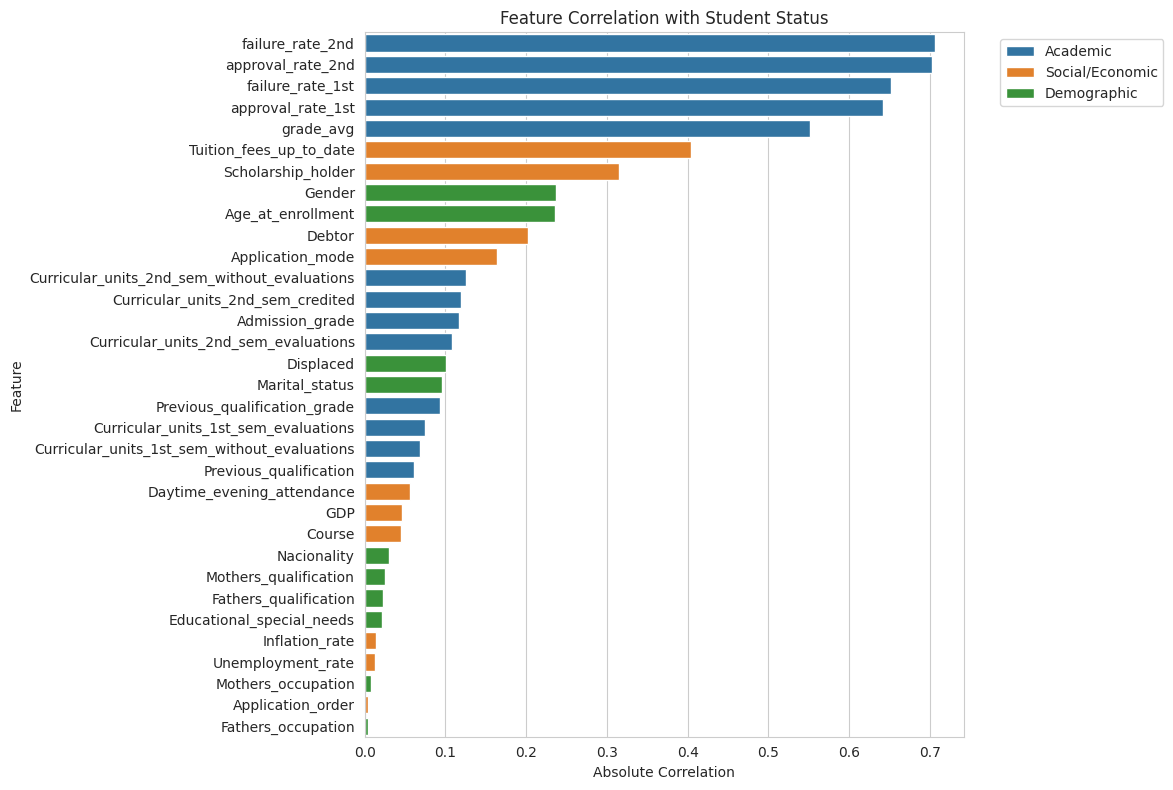

In [17]:
#Bar plot grouped by category
corr_df = pd.DataFrame({'Feature': correlations.index, 'Correlation': correlations.values})
corr_df['Group'] = corr_df['Feature'].apply(lambda x:
    'Demographic' if x in demographic else
    'Academic' if x in academic else
    'Social/Economic')

plt.figure(figsize=(12, 8))
sns.barplot(data=corr_df.sort_values('Correlation', ascending=False),
            x='Correlation', y='Feature', hue='Group', dodge=False)
plt.title('Feature Correlation with Student Status')
plt.xlabel('Absolute Correlation')
plt.ylabel('Feature')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [18]:
print(f"\nTrain shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train class distribution:\n{pd.Series(y_train).value_counts(normalize=True)}")


Train shape: (3539, 35), Test shape: (885, 35)
Train class distribution:
Status_encoded
2    0.499294
0    0.321277
1    0.179429
Name: proportion, dtype: float64


In [19]:
#winsorization
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
bounds = {}  # store (lower, upper) for each numeric column

for col in numeric_cols:
    lower = X_train[col].quantile(0.01)
    upper = X_train[col].quantile(0.99)
    bounds[col] = (lower, upper)

#Apply capping to training dataset
X_train_capped = X_train.copy()
for col in numeric_cols:
    lower, upper = bounds[col]
    X_train_capped[col] = X_train_capped[col].clip(lower, upper)

#Apply SAME bounds to test dataset
X_test_capped = X_test.copy()
for col in numeric_cols:
    lower, upper = bounds[col]
    X_test_capped[col] = X_test_capped[col].clip(lower, upper)

#check
print(f"Training size after capping: {X_train_capped.shape[0]} (no rows removed)")
print(f"Test size after capping: {X_test_capped.shape[0]} (no rows removed)")


Training size after capping: 3539 (no rows removed)
Test size after capping: 885 (no rows removed)


In [20]:
#Apply SMOTE only to training data to balance
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_capped, y_train)

print(f"Original training size: {X_train_capped.shape[0]}")
print(f"Balanced training size: {X_train_balanced.shape[0]}")
print(f"New class distribution:\n{pd.Series(y_train_balanced).value_counts(normalize=True)}")

Original training size: 3539
Balanced training size: 5301
New class distribution:
Status_encoded
2    0.333333
0    0.333333
1    0.333333
Name: proportion, dtype: float64


## Modeling

### Train Random Forest

In [21]:
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_base.fit(X_train_balanced, y_train_balanced)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [22]:
y_pred_base = rf_base.predict(X_test_capped)
y_proba_base = rf_base.predict_proba(X_test_capped)

In [23]:
#Hyperparameter Tuning (GridSearchCV)
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [15, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced', None]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_tuned = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf_tuned,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_balanced, y_train_balanced)
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test_capped)
y_proba_tuned = best_rf.predict_proba(X_test_capped)

print("\nBest parameters:", grid_search.best_params_)
print(f"Best Cross-Validation F1 score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 32 candidates, totalling 160 fits

Best parameters: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation F1 score: 0.8405


## Evaluation

In [24]:
#metric for base model
acc_base = accuracy_score(y_test, y_pred_base)
auc_base = roc_auc_score(y_test, y_proba_base, multi_class='ovr', average='weighted')

#metrics for tuned model
acc_tuned = accuracy_score(y_test, y_pred_tuned)
auc_tuned = roc_auc_score(y_test, y_proba_tuned, multi_class='ovr', average='weighted')

In [25]:
print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)

print(f"{'Metric':<15} {'Base RF':<12} {'Tuned RF':<12}")
print(f"{'Accuracy':<15} {acc_base:<12.4f} {acc_tuned:<12.4f}")
print(f"{'ROC AUC (weighted)':<15} {auc_base:<12.4f} {auc_tuned:<12.4f}")
print(f"{'Improvement (Acc)':<15} {'':<12} {acc_tuned - acc_base:<+12.4f}")

print("\n--- Classification Report (Tuned Model) ---")
print(classification_report(y_test, y_pred_tuned, target_names=le.classes_))


MODEL PERFORMANCE COMPARISON
Metric          Base RF      Tuned RF    
Accuracy        0.7548       0.7638      
ROC AUC (weighted) 0.8980       0.9005      
Improvement (Acc)              +0.0090     

--- Classification Report (Tuned Model) ---
              precision    recall  f1-score   support

     Dropout       0.82      0.75      0.78       284
    Enrolled       0.51      0.51      0.51       159
    Graduate       0.82      0.87      0.84       442

    accuracy                           0.76       885
   macro avg       0.72      0.71      0.71       885
weighted avg       0.76      0.76      0.76       885



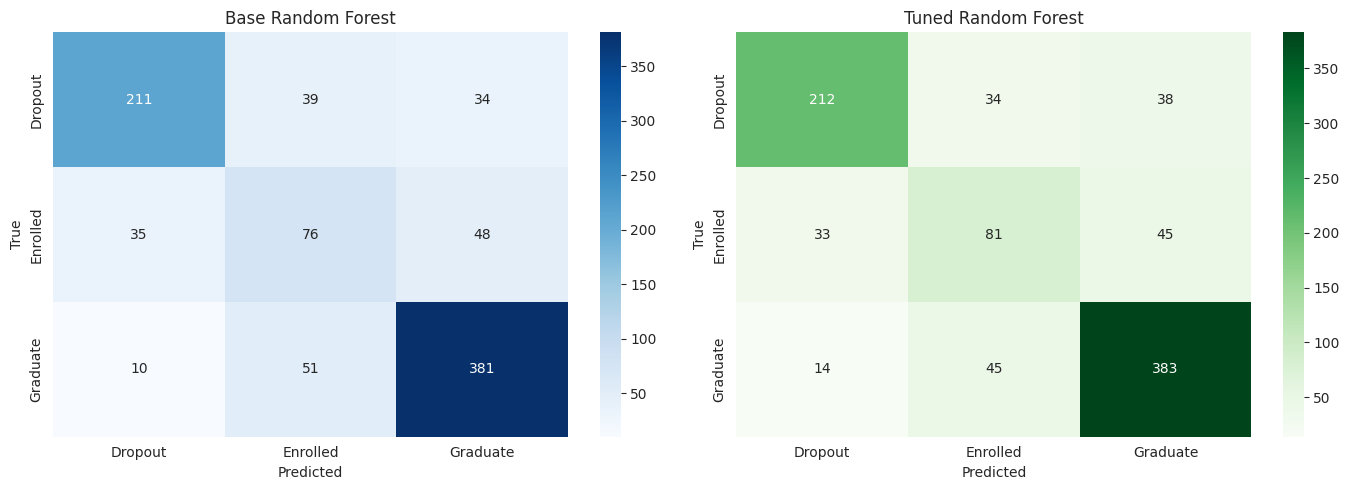

In [26]:
#Confusion Matrixes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_base), annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Base Random Forest')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

sns.heatmap(confusion_matrix(y_test, y_pred_tuned), annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title('Tuned Random Forest')
axes[1].set_ylabel('True')
axes[1].set_xlabel('Predicted')
plt.tight_layout()
plt.show()

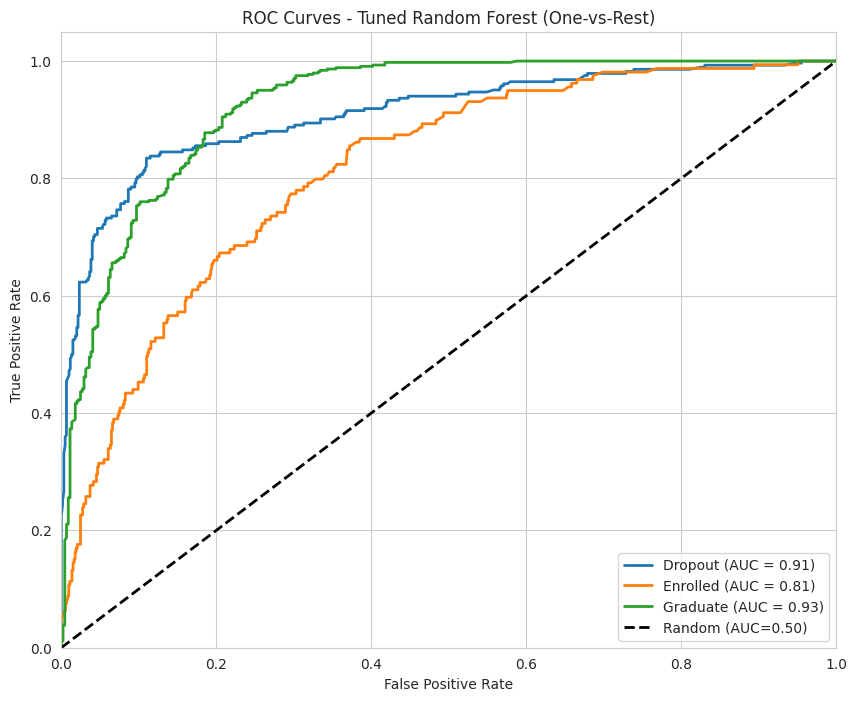

In [27]:
#ROC Curves (multi-class)
plt.figure(figsize=(10, 8))
for i, class_name in enumerate(le.classes_):
    # Get binary labels for this class (1 if class == i else 0)
    y_test_binary = (y_test == i).astype(int)
    y_score = y_proba_tuned[:, i]  # probability of this class

    fpr, tpr, _ = roc_curve(y_test_binary, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{class_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC=0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Tuned Random Forest (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

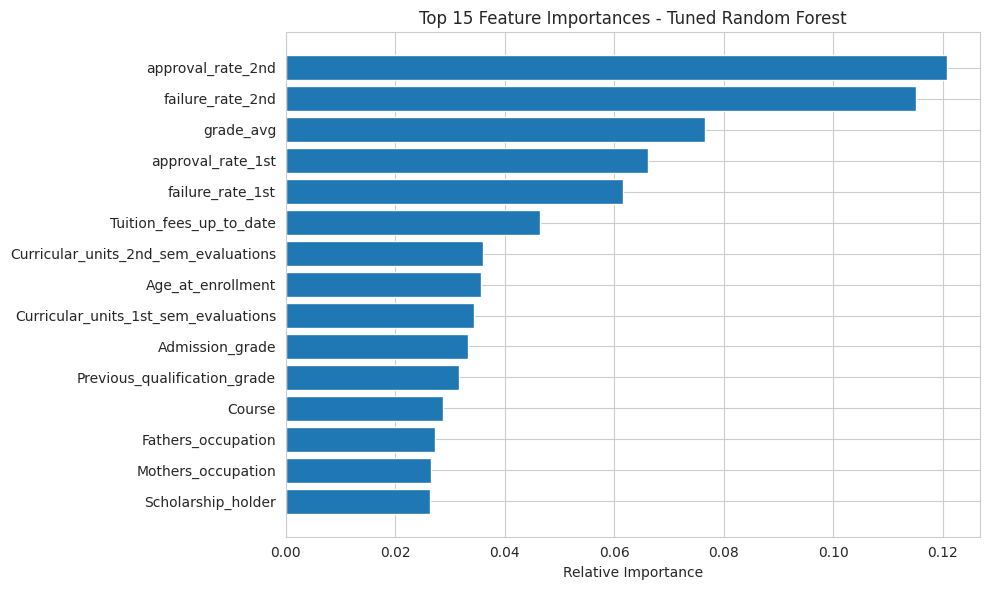

In [28]:
#Feature Importances (Tuned Model)
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(10, 6))
plt.title('Top 15 Feature Importances - Tuned Random Forest')
plt.barh(range(15), importances[indices][::-1], align='center')
plt.yticks(range(15), [X.columns[i] for i in indices][::-1])
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()

In [29]:
#Group Importance
group_importance = {}
for group_name, group_features in [('Demographic', demographic),
                                   ('Academic', academic),
                                   ('Social/Economic', social_economic)]:
    group_imp = 0
    for feat in group_features:
        if feat in X.columns:
            idx = X.columns.get_loc(feat)
            group_imp += importances[idx]
    group_importance[group_name] = group_imp

print("\nTotal feature importance per group (tuned model):")
for group, imp in sorted(group_importance.items(), key=lambda x: x[1], reverse=True):
    print(f"  {group}: {imp:.4f}")


Total feature importance per group (tuned model):
  Academic: 0.5992
  Social/Economic: 0.2253
  Demographic: 0.1664


#Save Best Model

In [30]:
joblib.dump(best_rf, 'best_model.pkl')
joblib.dump(bounds, 'bounds.pkl')
joblib.dump(numeric_cols, 'numeric_cols.pkl')
joblib.dump(X.columns.tolist(), 'feature_names.pkl')
joblib.dump(le, 'label_encoder.pkl')
print("\nBest model saved as 'best_model.pkl'")


Best model saved as 'best_model.pkl'
